# Entrega de pratica de Ciência de dados
- Gabriel Koji Kondo 3°I

## Hipótese Inicial

##### O problema central reside na inconsistência da classificação de perfis comportamentais dos clientes (Conservador, Moderado e Arrojado), conforme evidenciado pelas análises exploratórias no notebook. Embora essas categorias sejam atribuídas a todos os clientes, os dados revelam que muitos não aderem estritamente aos padrões esperados, com presença significativa de outliers nos gráficos de distribuição. Isso sugere limitações na definição atual dos perfis, que não capturam adequadamente o comportamento real dos investidores.

##### Um exemplo claro é observado no percentual de renda fixa: clientes classificados como "conservadores" que, teoricamente, deveriam priorizar investimentos de baixo risco com altos percentuais nessa categoria frequentemente desviam do padrao. Dos 178 clientes rotulados como conservadores, 27 (aproximadamente 15,17%) possuem percentual de renda fixa inferior a 50%, o que contraria a expectativa típica para esse perfil. Essa discrepância é visualizada nos boxplots, onde outliers indicam variações substanciais dentro de cada grupo.

##### Análises similares em outras métricas, como quantidade de ativos distintos, percentual de ações, FIIS e concentração da maior posição na carteira e a relação entre a porcetagem de renda fixa com a porcentagem de ações por tipo de usuário, reforçam o padrão: perfis declarados não refletem consistentemente o comportamento observado, com distribuições amplas e exceções que questionam a eficácia da classificação atual.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_raw = pd.read_csv('./carteiras_clientes.csv', encoding='ISO-8859-1')

print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (500, 16)


,id_cliente,idade,anos_como_cliente,patrimonio_declarado_R$,valor_total_investido_R$,perc_renda_fixa,perc_acoes,perc_fiis,perc_crypto,perc_exterior,qtd_ativos_distintos,operacoes_por_mes,prazo_medio_posicao_dias,maior_posicao_pct_carteira,tem_assessor,perfil_declarado_pelo_cliente
0,50309,49,9.2,80000,55095,19.6,28.2,40.5,2.7,8.9,22,1,235,18.7,sim,moderado
1,50014,59,4.1,1065676,991610,75.1,1.5,19.7,0.3,3.4,7,1,585,52.2,nao,conservador
2,50415,33,0.1,38627,14705,87.3,2.3,4.8,3.6,2.0,4,1,152,80.9,nao,conservador
3,50033,57,4.5,929700,603565,78.8,5.7,3.7,6.4,5.3,6,2,653,48.1,sim,conservador
4,50461,26,1.6,58771,30882,72.3,14.1,9.1,3.1,1.5,1,1,158,86.5,nao,moderado
5,50156,44,1.1,333774,184418,12.4,39.0,7.7,30.9,10.1,18,34,44,21.0,sim,arrojado
6,50250,38,6.3,1303811,968441,30.5,25.6,34.6,1.4,8.0,8,4,395,24.8,sim,conservador
7,50218,32,1.5,245718,195349,2.1,53.9,8.2,28.6,7.2,4,26,32,17.7,nao,arrojado
8,50222,32,4.5,860142,585148,27.8,51.4,16.6,0.7,3.4,4,3,651,27.5,nao,conservador
9,50294,28,1.7,1228382,832451,29.3,25.3,38.5,1.6,5.3,12,4,257,39.2,sim,moderado


### Gráfico sobre quantidade percentual de renda fixa por tipo de perfil

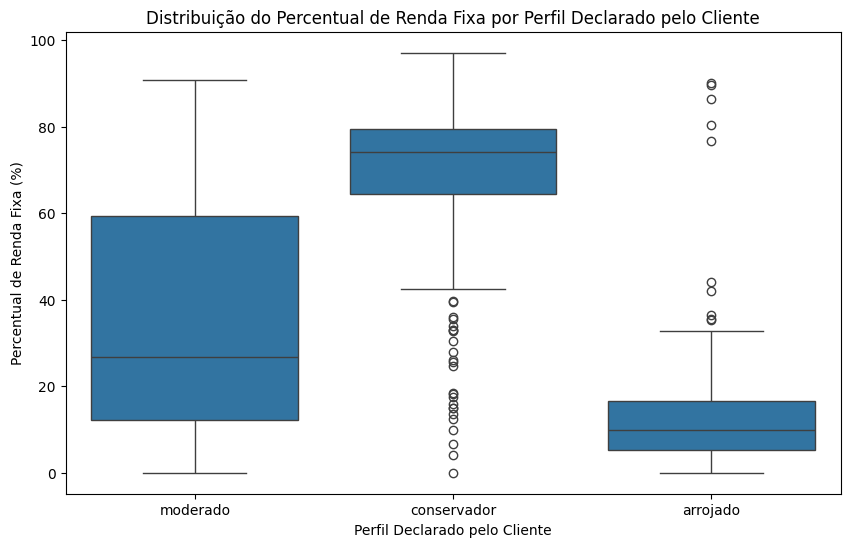

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='perfil_declarado_pelo_cliente', y='perc_renda_fixa')
plt.title('Distribuição do Percentual de Renda Fixa por Perfil Declarado pelo Cliente')
plt.xlabel('Perfil Declarado pelo Cliente')
plt.ylabel('Percentual de Renda Fixa (%)')
plt.show()

### Pequena análise contendo a porcentagem de clientes que tem o perfil com porcentagem de ativos em renda fixa menor que 50% e tem o perfil como conservador

In [ ]:
total_conservadores = len(df_raw[df_raw['perfil_declarado_pelo_cliente'] == 'conservador'])
print(f"Total de clientes conservadores: {total_conservadores}")

conservadores_baixa_renda_fixa = df_raw[(df_raw['perfil_declarado_pelo_cliente'] == 'conservador') & (df_raw['perc_renda_fixa'] < 50)]
quantidade = len(conservadores_baixa_renda_fixa)
print(f"Quantidade de clientes conservadores com percentual de renda fixa menor que 50%: {quantidade}")

print(f"Porcentagem de clientes que tem a porcentagem de renda fixa menor que 50% {(quantidade/total_conservadores)*100}%")

Total de clientes conservadores: 178
Quantidade de clientes conservadores com percentual de renda fixa menor que 50%: 27
Porcentagem de clientes que tem a porcentagem de renda fixa menor que 50% 15.168539325842698%


### Gráfico com 'Distribuição do Percentual de quantidade de ativos distintos por Perfil Declarado pelo Cliente

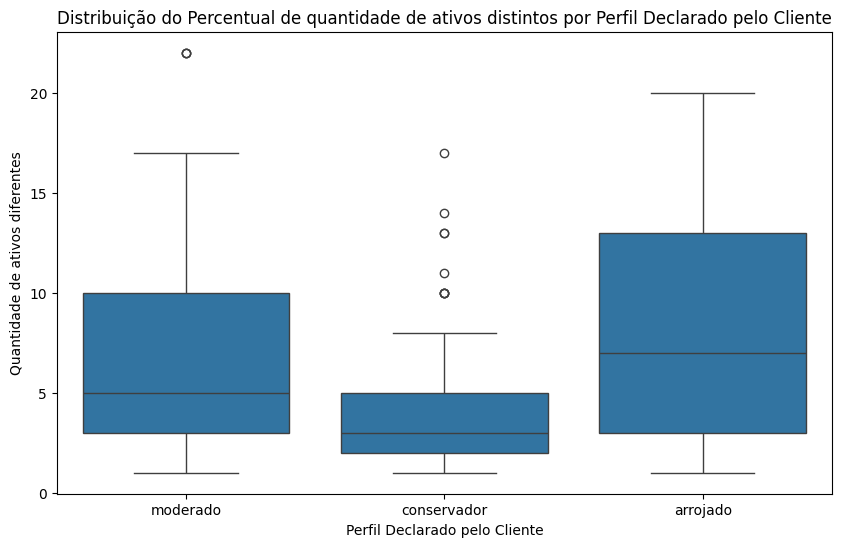

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='perfil_declarado_pelo_cliente', y='qtd_ativos_distintos')
plt.title('Distribuição do Percentual de quantidade de ativos distintos por Perfil Declarado pelo Cliente')
plt.xlabel('Perfil Declarado pelo Cliente')
plt.ylabel('Quantidade de ativos diferentes')
plt.show()

# Gráfico com Distribuição do Percentual de Ações por Perfil Declarado pelo Cliente

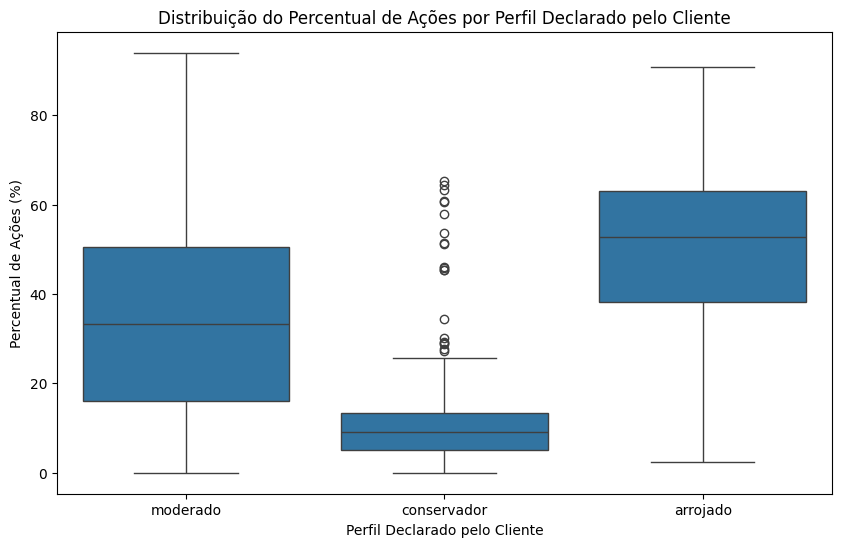

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='perfil_declarado_pelo_cliente', y='perc_acoes')
plt.title('Distribuição do Percentual de Ações por Perfil Declarado pelo Cliente')
plt.xlabel('Perfil Declarado pelo Cliente')
plt.ylabel('Percentual de Ações (%)')
plt.show()

# Gráfico com Distribuição do Percentual de FIIS por Perfil Declarado pelo Cliente

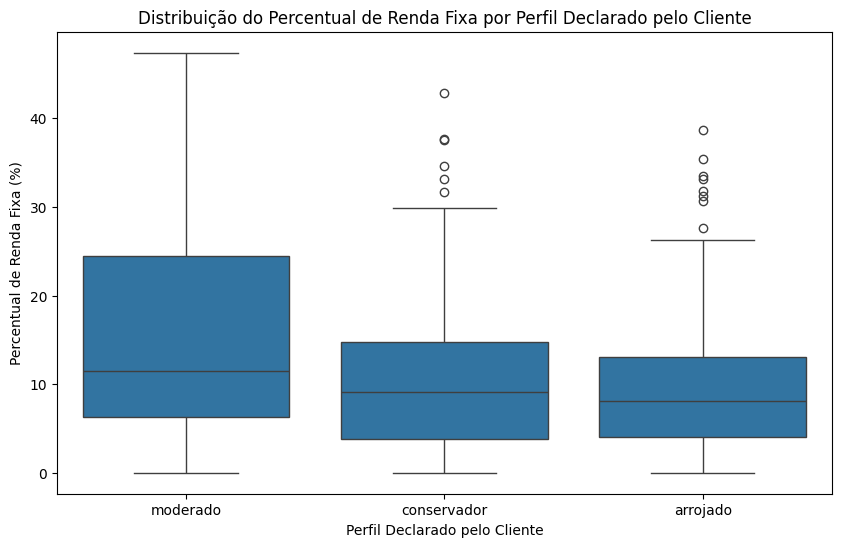

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='perfil_declarado_pelo_cliente', y='perc_fiis')
plt.title('Distribuição do Percentual de FIIS por Perfil Declarado pelo Cliente')
plt.xlabel('Perfil Declarado pelo Cliente')
plt.ylabel('Percentual de FIIS (%)')
plt.show()

In [10]:
display(df_raw['maior_posicao_pct_carteira'])

0      18.7
1      52.2
2      80.9
3      48.1
4      86.5
       ... 
495    48.5
496    56.6
497    40.4
498    34.9
499    42.6
Name: maior_posicao_pct_carteira, Length: 500, dtype: float64

# Gráfico com Distribuição do Percentual de qual a porcentagem em que o maior ativo tem em relação a carteira por Perfil Declarado pelo Cliente

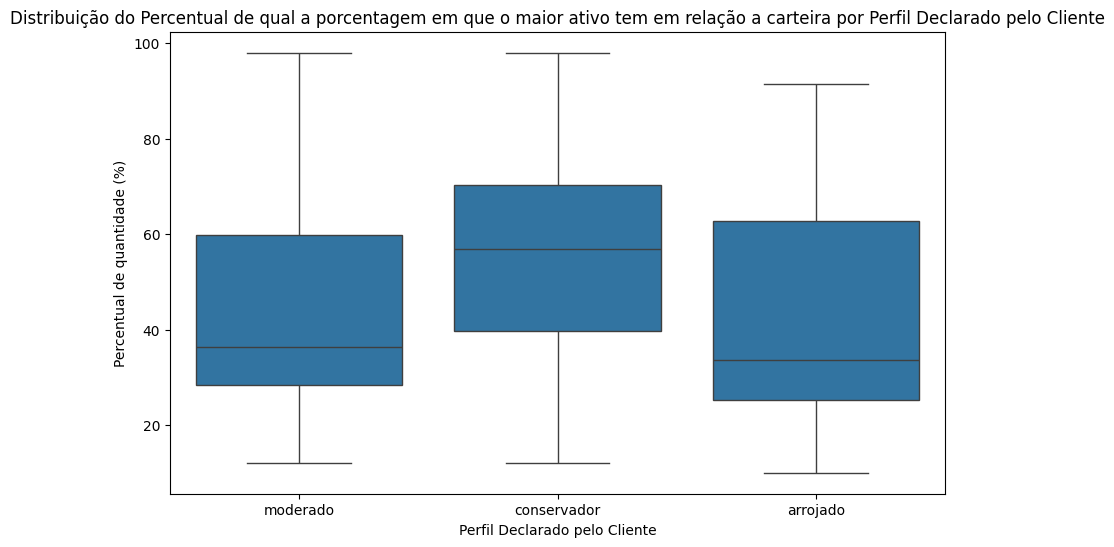

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='perfil_declarado_pelo_cliente', y='maior_posicao_pct_carteira')
plt.title('Distribuição do Percentual de qual a porcentagem em que o maior ativo tem em relação a carteira por Perfil Declarado pelo Cliente')
plt.xlabel('Perfil Declarado pelo Cliente')
plt.ylabel('Percentual de quantidade (%)')
plt.show()

## Gráfico que contem Relação entre Percentual de Renda Fixa e Ações por Perfil Declarado

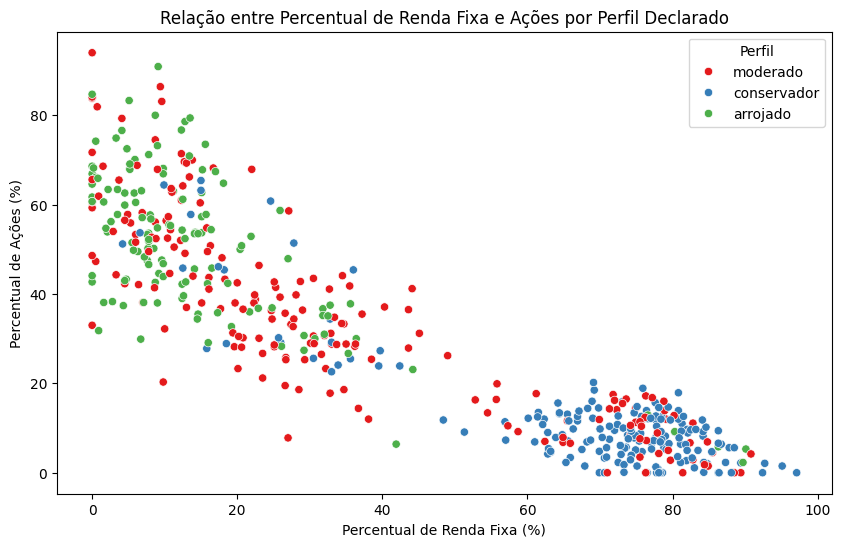

In [21]:
# Scatter plot para visualizar a relação entre percentual de renda fixa e ações, colorido por perfil
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_raw, x='perc_renda_fixa', y='perc_acoes', hue='perfil_declarado_pelo_cliente', palette='Set1')
plt.title('Relação entre Percentual de Renda Fixa e Ações por Perfil Declarado')
plt.xlabel('Percentual de Renda Fixa (%)')
plt.ylabel('Percentual de Ações (%)')
plt.legend(title='Perfil')
plt.show()

### Plano de Modelagem

### Itens a considerar

- id_cliente
- idade
- anos_como_cliente
- patrimonio_declarado_R$
- valor_total_investido_R$
- perc_renda_fixa
- perc_acoes
- perc_fiis
- qtd_ativos_distintos
- operacoes_por_mes
- maior_posicao_pct_carteira

 ### Nao vou usar estas
- perc_crypto
- perc_exterior
- prazo_medio_posicao_dias
- tem_assessor
- perfil_declarado_pelo_cliente
( Não usar )